# Aircrash Analysis Python
## Research Questions
#### 1. How have aircraft crashes trended over the years?
#### 2. Which countries recorded the most aircraft crashes?
#### 3. Which operators or airlines were involved in the most crashes?
#### 4. Which aircraft types appeared most in crash records?
#### 5. Which months historically record the most crashes?
#### 6. What is the difference between fatalities in the air, casualties on ground, and those aboard?
#### 7. What proportion of crashes had zero survivors?

# Cleaning using EDA

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv("aircrahesFullDataUpdated_2024.csv")
df.head()

,Year,Quarter,Month,Day,Country/Region,Aircraft Manufacturer,Aircraft,Location,Operator,Ground,Fatalities (air),Aboard
0,1970,Qtr 2,April,28,NaN,de Havilland Canada,de Havilland Canada DHC 6 Twin Otter 100VH,Kainatu,Airlines Australia GuineaTrans New,0,8,11
1,1952,Qtr 2,April,30,NaN,Douglas,Douglas DC 3VT,Delhi,Airways IndiaDeccan,0,9,9
2,1973,Qtr 2,April,10,NaN,Vickers Vanguard,Vickers Vanguard 952G AXOP,Near Basel,(UK) Airlines International SwitzerlandInvicta,0,108,145
3,2000,Qtr 2,April,19,'-,Antonov,Antonov AN 8TL,Pepa -,Airlines Centrafricain,0,24,24
4,1946,Qtr 2,April,30,'-,Douglas,Douglas C 47A FZ559,Pindi-Khut -,Force Air Royal,0,12,12


In [28]:
df.dtypes

Year                      int64
Quarter                  object
Month                    object
Day                       int64
Country/Region           object
Aircraft Manufacturer    object
Aircraft                 object
Location                 object
Operator                 object
Ground                    int64
Fatalities (air)          int64
Aboard                    int64
dtype: object

In [29]:
df.shape

(5035, 12)

In [30]:
df.isnull().sum()

Year                       0
Quarter                    0
Month                      0
Day                        0
Country/Region           230
Aircraft Manufacturer      0
Aircraft                   0
Location                   0
Operator                 234
Ground                     0
Fatalities (air)           0
Aboard                     0
dtype: int64

In [31]:
print(df['Country/Region'].value_counts(dropna=False))

Country/Region
Russia         249
NaN            230
Brazil         162
Colombia       146
New            142
              ... 
Russian          1
Phillipines      1
Oltenia          1
Morroco          1
Montserrat       1
Name: count, Length: 528, dtype: int64


In [32]:
print(df['Operator'].value_counts(dropna=False))

Operator
NaN                                                   234
Aeroflot                                              188
Force Air U.S. - Military                              92
France Air                                             57
Lufthansa Deutsche                                     57
                                                     ... 
California         Barbara Santa Southwest Airways      1
Cityhopper KLM                                          1
Inc. Services Aero El - Taxi Air                        1
Aviaiton England HampshireNew                           1
Airlines Shanxi                                         1
Name: count, Length: 2632, dtype: int64


In [33]:
df['Country/Region'] = df['Country/Region'].fillna("Unknown")
df['Operator'] = df['Operator'].fillna("Unknown")

In [34]:
df["Country/Region"] = df["Country/Region"].str.strip()
df["Aircraft Manufacturer"] = df["Aircraft Manufacturer"].str.strip()
df["Aircraft"] = df["Aircraft"].str.strip()
df["Location"] = df["Location"].str.strip()
df["Operator"] = df["Operator"].str.strip()

In [35]:
df["Country/Region"] = df["Country/Region"].str.title()
df["Aircraft Manufacturer"] = df["Aircraft Manufacturer"].str.title()
df["Aircraft"] = df["Aircraft"].str.title()
df["Location"] = df["Location"].str.title()
df["Operator"] = df["Operator"].str.title()

In [36]:
print((df == "'-").sum())


Year                     0
Quarter                  0
Month                    0
Day                      0
Country/Region           4
Aircraft Manufacturer    0
Aircraft                 0
Location                 0
Operator                 0
Ground                   0
Fatalities (air)         0
Aboard                   0
dtype: int64


In [37]:
df = df.replace("'-", "Unknown")
print((df == "'-").sum())

Year                     0
Quarter                  0
Month                    0
Day                      0
Country/Region           0
Aircraft Manufacturer    0
Aircraft                 0
Location                 0
Operator                 0
Ground                   0
Fatalities (air)         0
Aboard                   0
dtype: int64


In [38]:
print(sorted(df['Country/Region'].unique().astype(str)))

[np.str_('10'), np.str_('100'), np.str_('110'), np.str_('116'), np.str_('18'), np.str_('325'), np.str_('570'), np.str_('800'), np.str_('Aaland'), np.str_('Aargau'), np.str_('Afghanistan'), np.str_('Afghanstan'), np.str_('Africa'), np.str_('Aichi'), np.str_('Air'), np.str_('Airlines'), np.str_('Airzona'), np.str_('Akalaska'), np.str_('Alabama'), np.str_('Alaksa'), np.str_('Alakska'), np.str_('Alaska'), np.str_('Albania'), np.str_('Alberta'), np.str_('Algarve'), np.str_('Algeria'), np.str_('American'), np.str_('Amsterdam'), np.str_('Angola'), np.str_('Aregntina'), np.str_('Argentina'), np.str_('Argentinade'), np.str_('Argyll'), np.str_('Arizona'), np.str_('Ariège'), np.str_('Arkansas'), np.str_('Armenia'), np.str_('Atlantic'), np.str_('Australia'), np.str_('Australila'), np.str_('Austria'), np.str_('Ayrshire'), np.str_('Azerbaijan'), np.str_('Azerbaijan\r\n\t\r\nBakou'), np.str_('Azores'), np.str_('Azuay'), np.str_('Baangladesh'), np.str_('Bahamas'), np.str_('Bahrain'), np.str_('Bali'), 

In [39]:
df['Country/Region'] = df['Country/Region'].replace(['10', '100', '110', '116', '18', '325', '570', '800'], "Unknown")

In [40]:
mapping = {
    'Afghanstan': 'Afghanistan',
    'American': 'USA',
    'Brazil\tAmazonaves': 'Brazil',
    'Brazil\tLoide': 'Brazil',
    'Brazil\r\nFlorianopolis': 'Brazil',
    'Cailifornia': 'California',
    'California?': 'California',
    'Californiia': 'California',
    'Calilfornia': 'California',
    'United': 'USA',
    'Us': 'USA',
    'Washingon': 'Washington',
}

df['Country/Region'] = df['Country/Region'].replace(mapping)

In [41]:
us_states = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado",
    "Connecticut", "Delaware", "Florida", "Georgia", "Hawaii", "Idaho",
    "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana",
    "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota",
    "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada",
    "New Hampshire", "New Jersey", "New Mexico", "New York",
    "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon",
    "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota",
    "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington",
    "West Virginia", "Wisconsin", "Wyoming"
]

df["Country/Region"] = df["Country/Region"].apply(
    lambda x: "USA" if x in us_states else x
)

In [42]:
df["Survivors"] = df["Aboard"] - df["Fatalities (air)"]

In [43]:
df.head(6)

,Year,Quarter,Month,Day,Country/Region,Aircraft Manufacturer,Aircraft,Location,Operator,Ground,Fatalities (air),Aboard,Survivors
0,1970,Qtr 2,April,28,Unknown,De Havilland Canada,De Havilland Canada Dhc 6 Twin Otter 100Vh,Kainatu,Airlines Australia Guineatrans New,0,8,11,3
1,1952,Qtr 2,April,30,Unknown,Douglas,Douglas Dc 3Vt,Delhi,Airways Indiadeccan,0,9,9,0
2,1973,Qtr 2,April,10,Unknown,Vickers Vanguard,Vickers Vanguard 952G Axop,Near Basel,(Uk) Airlines International Switzerlandinvicta,0,108,145,37
3,2000,Qtr 2,April,19,Unknown,Antonov,Antonov An 8Tl,Pepa -,Airlines Centrafricain,0,24,24,0
4,1946,Qtr 2,April,30,Unknown,Douglas,Douglas C 47A Fz559,Pindi-Khut -,Force Air Royal,0,12,12,0
5,1960,Qtr 2,April,14,Unknown,Douglas,Douglas Dc 4?,Taipei -,Force Air Thai Royal,0,18,18,0


In [44]:
df.columns

Index(['Year', 'Quarter', 'Month', 'Day', 'Country/Region',
       'Aircraft Manufacturer', 'Aircraft', 'Location', 'Operator', 'Ground',
       'Fatalities (air)', 'Aboard', 'Survivors'],
      dtype='object')

# Charts and Graphs

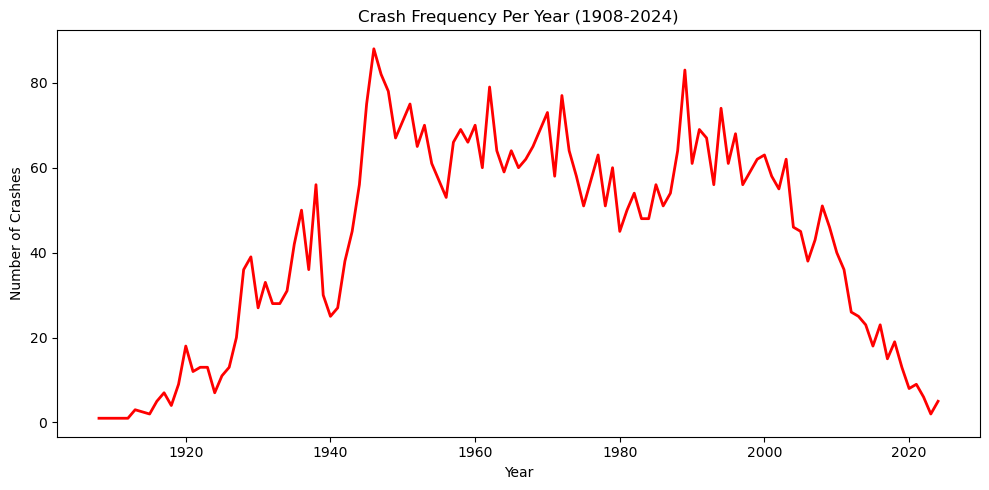

In [56]:
# Question 1
# How have aircraft crashes trended over the years?

year_counts = df["Year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values, color="red", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.title("Crash Frequency Per Year (1908-2024)")
plt.tight_layout()
plt.show()

Insight: Crash frequency rose sharply through the mid-20th century as commercial 
aviation expanded globally. A peak is visible around the 1950s–1990s, after which 
improved safety regulations, better aircraft engineering, and pilot training standards 
contributed to a steady long-term decline into the 2000s and 2020s.

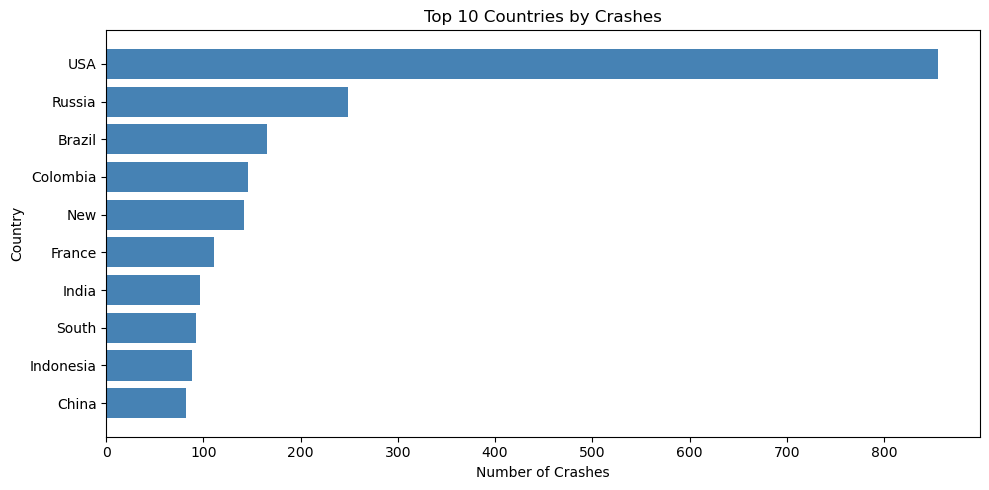

In [57]:
# Question 2
# Which countries recorded the most aircraft crashes?

country_counts = df["Country/Region"].value_counts()
country_counts = country_counts[country_counts.index != "Unknown"].head(10)

plt.figure(figsize=(10,5))
plt.barh(country_counts.index, country_counts.values, color="steelblue")
plt.xlabel("Number of Crashes")
plt.ylabel("Country")
plt.title("Top 10 Countries by Crashes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Insights: USA leads significantly in total recorded crashes, 
reflecting its long aviation history and the sheer volume of flights operated 
since the early 1900s. Russia and other countries with large military aviation 
programmes also feature prominently in the top 10.

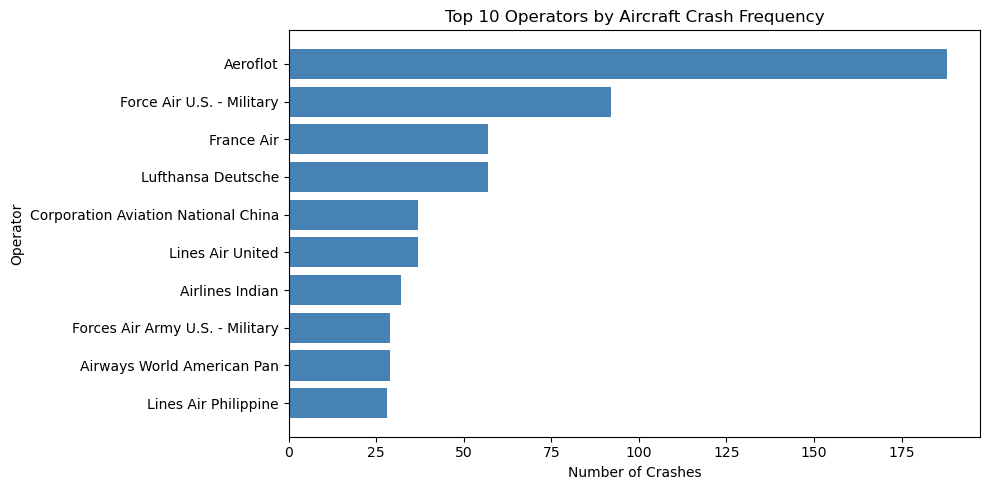

In [58]:
# Question 3
# Which operators or airlines were involved in the most crashes?

opt_counts = df["Operator"].value_counts()
opt_counts = opt_counts[opt_counts.index != "Unknown"].head(10)

plt.figure(figsize=(10,5))
plt.barh(opt_counts.index, opt_counts.values, color="steelblue")
plt.xlabel("Number of Crashes")
plt.ylabel("Operator")
plt.title("Top 10 Operators by Aircraft Crash Frequency")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Insights: Military operators dominate this list, which is expected given that 
military aviation involves more risk, more flights in adverse conditions, and 
spans the entire history of aviation. Among commercial carriers, the operators 
with the most crashes are generally those that have operated the longest or 
across the most routes.

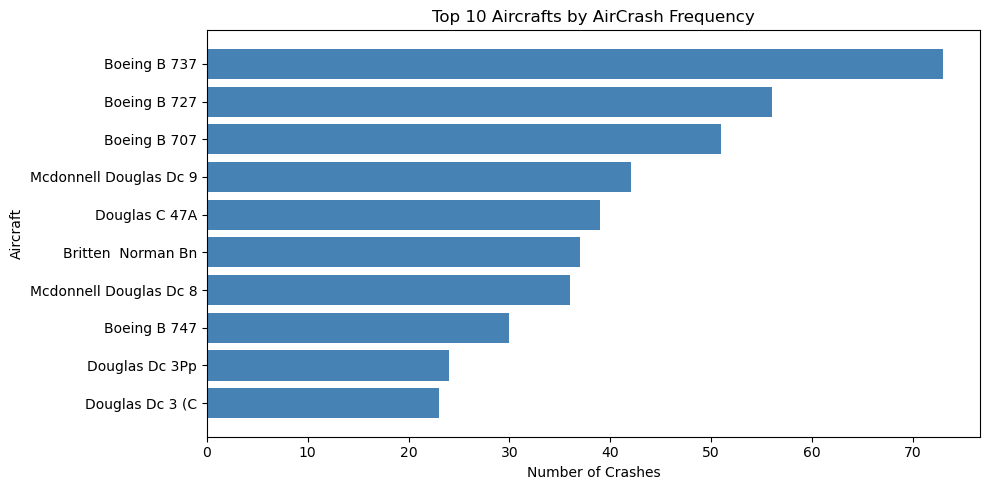

In [59]:
# Question 4
# Which aircraft types appeared most in crash records?

aft_counts = df["Aircraft"].value_counts()
aft_counts = aft_counts[aft_counts.index != "Unknown"].head(10)

plt.figure(figsize=(10,5))
plt.barh(aft_counts.index, aft_counts.values, color="steelblue")
plt.xlabel("Number of Crashes")
plt.ylabel("Aircraft")
plt.title("Top 10 Aircrafts by AirCrash Frequency")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Insights: Older aircraft models from the mid-20th century dominate crash records, 
largely because they were produced in high volumes and operated during a period when 
safety standards were still maturing. Higher crash counts for a specific model do not 
necessarily mean the aircraft is unsafe — flight volume and era of operation matter greatly.

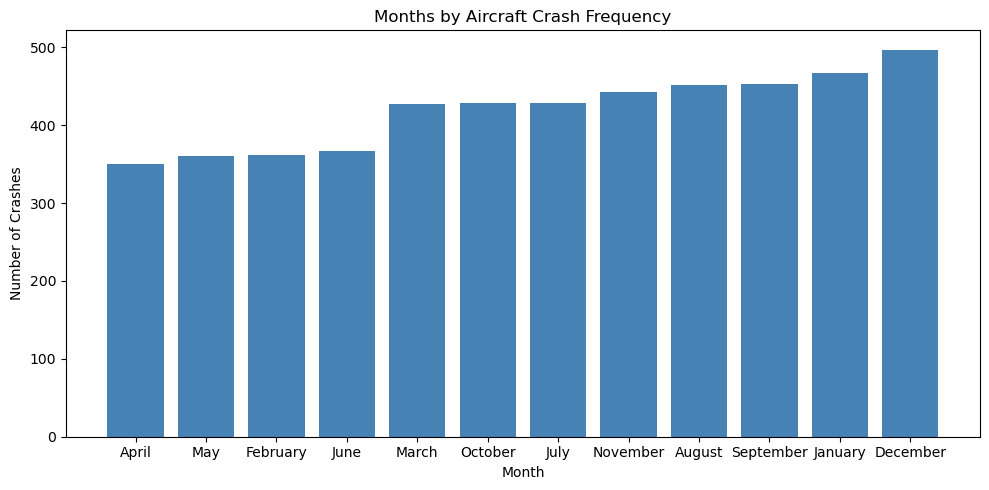

In [60]:
# Question 5
# Which months historically record the most crashes?
month_counts = df["Month"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(month_counts.index, month_counts.values, color="steelblue")
plt.ylabel("Number of Crashes")
plt.xlabel("Month")
plt.title("Months by Aircraft Crash Frequency")
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

Insights: Crash frequency varies across months, with certain months showing 
consistently higher numbers. This can be linked to seasonal weather patterns such as 
winter fog, icing conditions, and reduced visibility which increase the likelihood 
of incidents, particularly in the Northern Hemisphere.

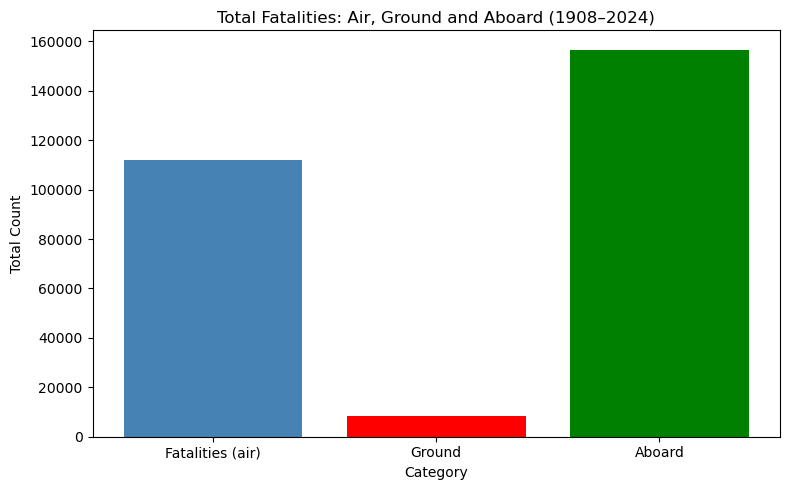

In [50]:
# Question 6
# Air vs Ground vs Aboard
fatality_totals = df[["Fatalities (air)", "Ground", "Aboard"]].sum()

plt.figure(figsize=(8, 5))
plt.bar(fatality_totals.index, fatality_totals.values, color=["steelblue", "red", "green"])
plt.title("Total Fatalities: Air, Ground and Aboard (1908–2024)")
plt.xlabel("Category")
plt.ylabel("Total Count")
plt.tight_layout()
plt.show()

Insights: The total aboard figure is expectedly the highest as it represents 
everyone on board regardless of outcome. Fatalities in the air make up the majority 
of deaths, while ground casualties — though smaller — represent innocent lives lost 
on the surface due to crashes into populated areas, a sad reminder of aviation's 
wider impact on communities.

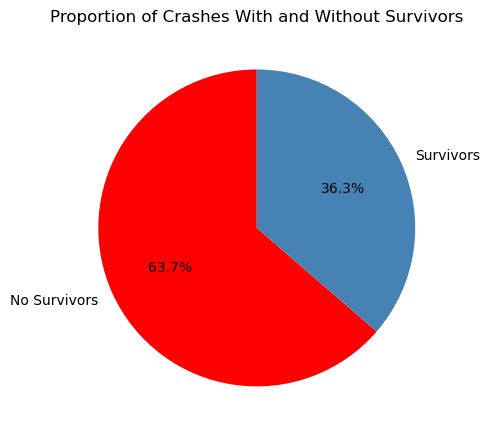

In [51]:
# Question 7
# What proportion of crashes had zero survivors?
survivor_counts = (df["Survivors"] == 0).value_counts()

plt.figure(figsize=(5, 5))
plt.pie(survivor_counts.values, 
        labels=["No Survivors", "Survivors"], 
        autopct="%1.1f%%", 
        colors=["red", "steelblue"],
        startangle=90)
plt.title("Proportion of Crashes With and Without Survivors")
plt.tight_layout()
plt.show()

Insights: A significant proportion of recorded crashes resulted in no survivors at all, 
underlining the historically fatal nature of aviation incidents. However, the share of 
crashes with at least one survivor shows that improved emergency response, aircraft 
design, and safety procedures have given passengers a better chance of survival 
in non-fatal incidents over time.